In [ ]:
import random
import copy
import math
import matplotlib.pyplot as plt
import numpy as np

base_requests = [1, 2, 3, 4, 5, 1, 2, 3, 4, 5]
distance = [
    [7770, 6896, 9292,  661, 5776, 7770, 6896, 9292,  661, 5776], 
    [1360, 9166, 8933, 4797, 2562, 1360, 9166, 8933, 4797, 2562],
    [5890, 9774, 8013, 1495,  564, 5890, 9774, 8013, 1495,  564],
    [5691, 3058, 3112, 8129, 8506, 5691, 3058, 3112, 8129, 8506],
    [6234, 8349, 7541, 9967, 3068, 6234, 8349, 7541, 9967, 3068],
    [6765, 2547, 6735, 1516, 5963, 6765, 2547, 6735, 1516, 5963],
    [ 966, 3247, 5986, 8369, 2527,  966, 3247, 5986, 8369, 2527],
    [4926, 9667, 7599, 6939, 3195, 4926, 9667, 7599, 6939, 3195],
    [6078,  689, 1275, 8392, 5758, 6078,  689, 1275, 8392, 5758],
    [8822, 3234, 8726, 7363, 6118, 8822, 3234, 8726, 7363, 6118],
    [2185, 3505, 3652, 8416, 7236, 2185, 3505, 3652, 8416, 7236],
    [1269, 5158, 2085, 9029,  891, 1269, 5158, 2085, 9029,  891],
    [7449, 2399, 4443, 1378, 6392, 7449, 2399, 4443, 1378, 6392],
    [2933, 8234, 8055, 9768, 4061, 2933, 8234, 8055, 9768, 4061],
    [5811, 1767, 3573, 5387, 6684, 5811, 1767, 3573, 5387, 6684],
    [5551, 2028, 1521, 5359, 3599, 5551, 2028, 1521, 5359, 3599],
    [7561, 3732,  528, 7075,  528, 7561, 3732,  528, 7075,  528],
    [7574, 5977, 8907,  858, 3393, 7574, 5977, 8907,  858, 3393],
    [9117,  102, 2261, 9443,  122, 9117,  102, 2261, 9443,  122],
    [ 801, 8643, 4722,  398, 5485,  801, 8643, 4722,  398, 5485],
]
duration = [
    [537, 199, 471, 838, 395, 537, 199, 471, 838, 395],
    [ 64, 269,  84,  91, 936,  64, 269,  84,  91, 936],
    [741, 807, 588, 796,  71, 741, 807, 588, 796,  71],
    [269,  68, 102, 985, 462, 269,  68, 102, 985, 462],
    [497, 395,  12, 404, 543, 497, 395,  12, 404, 543],
    [995, 385,  38, 996, 660, 995, 385,  38, 996, 660],
    [184, 803,  47, 134, 701, 184, 803,  47, 134, 701],
    [164, 317, 589, 816, 587, 164, 317, 589, 816, 587],
    [649, 636, 151, 395, 893, 649, 636, 151, 395, 893],
    [846,  29, 661, 100, 612, 846,  29, 661, 100, 612],
    [174, 913, 648, 882,  42, 174, 913, 648, 882,  42],
    [142, 404, 108, 625, 768, 142, 404, 108, 625, 768],
    [314, 181, 205, 757, 747, 314, 181, 205, 757, 747],
    [ 76, 703, 716, 898, 333,  76, 703, 716, 898, 333],
    [461, 587,  80,  33, 999, 461, 587,  80,  33, 999],
    [607, 127, 620,  47, 274, 607, 127, 620,  47, 274],
    [677, 205, 311,  81, 731, 677, 205, 311,  81, 731],
    [484, 991,  14, 187, 107, 484, 991,  14, 187, 107],
    [278, 733, 734, 762, 458, 278, 733, 734, 762, 458],
    [269,  85,  50, 893, 180, 269,  85,  50, 893, 180],
]
cum_order = [
    [3.75, 9.34, 6.22, 6.11, 1.01, 3.75, 9.34, 6.22, 6.11, 1.01],
    [9.54, 3.32, 4.06, 4.64, 3.19, 9.54, 3.32, 4.06, 4.64, 3.19],
    [0.36, 3.27, 2.68, 0.34, 0.50, 0.36, 3.27, 2.68, 0.34, 0.50],
    [4.14, 1.80, 2.70, 2.58, 3.42, 4.14, 1.80, 2.70, 2.58, 3.42],
    [3.24, 9.33, 2.17, 4.54, 7.87, 3.24, 9.33, 2.17, 4.54, 7.87],
    [1.39, 2.30, 8.43, 6.29, 1.13, 1.39, 2.30, 8.43, 6.29, 1.13],
    [4.34, 7.15, 3.79, 0.87, 5.05, 4.34, 7.15, 3.79, 0.87, 5.05],
    [9.41, 6.65, 4.07, 8.14, 5.86, 9.41, 6.65, 4.07, 8.14, 5.86],
    [2.46, 3.53, 2.90, 2.97, 4.48, 2.46, 3.53, 2.90, 2.97, 4.48],
    [8.97, 0.24, 9.37, 2.60, 8.02, 8.97, 0.24, 9.37, 2.60, 8.02],
    [1.18, 1.44, 9.76, 6.12, 3.23, 1.18, 1.44, 9.76, 6.12, 3.23],
    [1.42, 1.41, 9.32, 0.54, 2.47, 1.42, 1.41, 9.32, 0.54, 2.47],
    [0.27, 4.19, 0.68, 5.70, 6.18, 0.27, 4.19, 0.68, 5.70, 6.18],
    [4.90, 0.24, 1.13, 4.77, 7.14, 4.90, 0.24, 1.13, 4.77, 7.14],
    [6.26, 6.64, 2.57, 0.19, 4.24, 6.26, 6.64, 2.57, 0.19, 4.24],
    [1.71, 0.54, 6.12, 3.04, 4.12, 1.71, 0.54, 6.12, 3.04, 4.12],
    [7.07, 5.06, 3.26, 0.07, 0.08, 7.07, 5.06, 3.26, 0.07, 0.08],
    [7.60, 9.63, 9.11, 0.26, 8.72, 7.60, 9.63, 9.11, 0.26, 8.72],
    [4.67, 4.10, 9.04, 1.36, 4.38, 4.67, 4.10, 9.04, 1.36, 4.38],
    [1.46, 5.12, 5.58, 2.68, 6.25, 1.46, 5.12, 5.58, 2.68, 6.25],
]

base_order_rate = [26.0, 46.0, 10.0, 19.0, 47.0, 26.0, 46.0, 10.0, 17.0, 47.0]

taxis_battery = [100 for i in range(20)]

battery_treshold = 10


flat_duration = [item for row in duration for item in row]
min_duration = min(flat_duration)
max_duration = max(flat_duration)

flat_cumulative_order_rate = [item for row in cum_order for item in row]
min_cumulative_order_rate = min(flat_cumulative_order_rate)
max_cumulative_order_rate = max(flat_cumulative_order_rate)


min_base_order_rate = min(base_order_rate)
max_base_order_rate = max(base_order_rate)


alpha = 1
beta = 1
gamma = 1


def objective(taxi_assignments):
    fitness = 0
    miu = 0.1
    
    for i in range(len(taxi_assignments)):
        assigned_base_request = taxi_assignments[i]
        if assigned_base_request is not None:
            order_rate_at_request_base = base_order_rate[assigned_base_request]
            cummulative_order_route = cum_order[i][assigned_base_request]
            estimated_duration= duration[i][assigned_base_request]

            d_hat = max((estimated_duration - min_duration), estimated_duration) / max((max_duration - min_duration), estimated_duration)
            cumulative_hat = 0 if(cummulative_order_route == 0) else max((cummulative_order_route - min_cumulative_order_rate), cummulative_order_route) / max((max_cumulative_order_rate - min_cumulative_order_rate), cummulative_order_route)
            base_order_rate_hat = max((order_rate_at_request_base - min_base_order_rate), order_rate_at_request_base) / max((max_base_order_rate - min_base_order_rate), order_rate_at_request_base)                                                                                
            fir = (alpha * (1- d_hat)) + (beta * (1 - cumulative_hat)) + (gamma * base_order_rate_hat)

            
            fitness_component = fir
            fitness += fitness_component
    
    return fitness

def is_valid_solution(solution):
    """
    constraint: 
    1. seluruh base request diassign tepat untuk satu taksi (tidak lebih dan tidak kurang)
    2. battery constraint
    """
    
    assigned_requests = [req for req in solution if req is not None]
    if len(assigned_requests) != 10 or len(set(assigned_requests)) != 10:
        return False
    
    
    for i in range(len(solution)):
        assignment = solution[i]
        if assignment is not None:
            taxi_battery = taxis_battery[i]
            battery_consumption = 0.00024524 * distance[i][assignment] + 0 * duration[i][assignment]
            remaining_battery = taxi_battery - battery_consumption
            
            if remaining_battery < battery_treshold:
                return False
    
    return True

def generate_initial_solution(max_attempts=1000):
    for _ in range(max_attempts):
        
        solution = [None] * 20
        
        
        taxis_to_assign = random.sample(range(20), 10)
        
        
        requests = list(range(10))
        random.shuffle(requests)
        
        for i, taxi_idx in enumerate(taxis_to_assign):
            solution[taxi_idx] = requests[i]
        
        if is_valid_solution(solution):
            return solution
    
    
    return None

def get_neighbor(solution, max_attempts=50):
    for _ in range(max_attempts):
        
        neighbor = solution.copy()
        
        
        mod_type = random.choice(["swap", "reassign"])
        
        if mod_type == "swap":
            
            assigned_indices = [i for i, val in enumerate(neighbor) if val is not None]
            if len(assigned_indices) >= 2:
                i, j = random.sample(assigned_indices, 2)
                neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
        
        elif mod_type == "reassign":
            
            assigned_indices = [i for i, val in enumerate(neighbor) if val is not None]
            unassigned_indices = [i for i, val in enumerate(neighbor) if val is None]
            
            if assigned_indices and unassigned_indices:
                from_idx = random.choice(assigned_indices)
                to_idx = random.choice(unassigned_indices)
                
                neighbor[to_idx] = neighbor[from_idx]
                neighbor[from_idx] = None
        
        
        if is_valid_solution(neighbor):
            return neighbor
    
    
    return solution.copy()

def temperature_schedule(t, initial_temp, num_of_cycle):
    """
    mengubah pendekatan temperatur menjadi num of cycle
    """
    if t >= num_of_cycle:
        return 0
    
    
    return initial_temp * (1 - t / num_of_cycle)

def simulated_annealing(initial_temp, num_of_cycle, max_attempts=1000):    
    current = generate_initial_solution(max_attempts)
    
    
    if current is None:
        print("No valid initial solution found after", max_attempts, "attempts")
        return None, None
    
    current_value = objective(current)
    
    
    best = current.copy()
    best_value = current_value
    
    
    while True:
        
        T = temperature_schedule(t, initial_temp, num_of_cycle)
        
        
        if T == 0:
            
            if is_valid_solution(best):
                return best, best_value
            else:
                print("No valid solution found")
                return None, None
        
        
        next_state = get_neighbor(current)
        next_value = objective(next_state)
        
        
        delta_E = next_value - current_value
        
        
        if delta_E > 0:  
            current = next_state
            current_value = next_value
            
            
            if current_value > best_value:
                best = current.copy()
                best_value = current_value
        else:  
            if random.random() < math.exp(delta_E / T):
                current = next_state
                current_value = next_value
        

In [ ]:
import time

def plot_distributions(initial_temp=100, num_of_cycle=100, runs=1000, max_attempts=1000):
    fitness_values = []
    duration_values = []
    valid_runs = 0
    
    
    for i in range(runs):
            
        start_time = time.time()
        
        solution, fitness = simulated_annealing(
            initial_temp=initial_temp,
            num_of_cycle=num_of_cycle,
            max_attempts=max_attempts
        )
        
        end_time = time.time()
        duration = end_time - start_time
        duration_values.append(duration)
        
        if solution is not None and fitness is not None:
            fitness_values.append(fitness)
            valid_runs += 1
    
    if fitness_values:
        
        mean_fitness = np.mean(fitness_values)
        std_fitness = np.std(fitness_values)
        
        
        plt.figure(figsize=(8, 6))
        plt.hist(fitness_values, bins=20, edgecolor='black')
        plt.axvline(mean_fitness, linestyle='--', label=f'Mean = {mean_fitness:.2f}')
        plt.axvline(mean_fitness + std_fitness, color='gray', linestyle=':', 
                    label=f'Std = {std_fitness:.2f}')
        plt.title('Objective Function Score (Simulated Annealing)'.format(valid_runs))
        plt.xlabel('Fitness')
        plt.ylabel('Frequency')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        print(f"Mean fitness: {mean_fitness:.4f}")
        print(f"Std deviation of fitness: {std_fitness:.4f}")
    else:
        mean_fitness = None
        std_fitness = None
        print("No valid solutions found")
    
    
    if duration_values:
        
        mean_duration = np.mean(duration_values)
        std_duration = np.std(duration_values)
        
        
        plt.figure(figsize=(8, 6))
        plt.hist(duration_values, bins=20, edgecolor='black')
        plt.axvline(mean_duration, linestyle='--', label=f'Mean = {mean_duration:.4f}s')
        plt.axvline(mean_duration + std_duration, color='gray', linestyle=':', 
                    label=f'Std = {std_duration:.4f}s')
        plt.title('Computation Time (Simulated Annealing)'.format(runs))
        plt.xlabel('Time (seconds)')
        plt.ylabel('Frequency')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        print(f"Mean computation time: {mean_duration:.4f} seconds")
        print(f"Std deviation of time: {std_duration:.4f} seconds")
    else:
        mean_duration = None
        std_duration = None
        print("No runs completed to plot duration distribution")
    
    return mean_fitness, std_fitness, mean_duration, std_duration

Running 1000 trials of simulated annealing...
Completed 100 runs...
Completed 200 runs...
Completed 300 runs...
Completed 400 runs...
Completed 500 runs...
Completed 600 runs...
Completed 700 runs...
Completed 800 runs...
Completed 900 runs...
Valid solutions: 1000/1000 (100.00%)


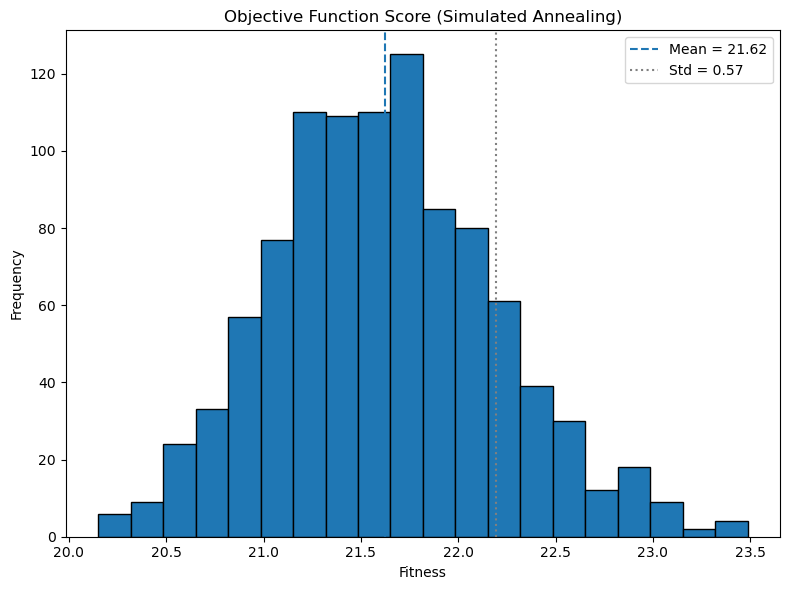

Mean fitness: 21.6232
Std deviation of fitness: 0.5706


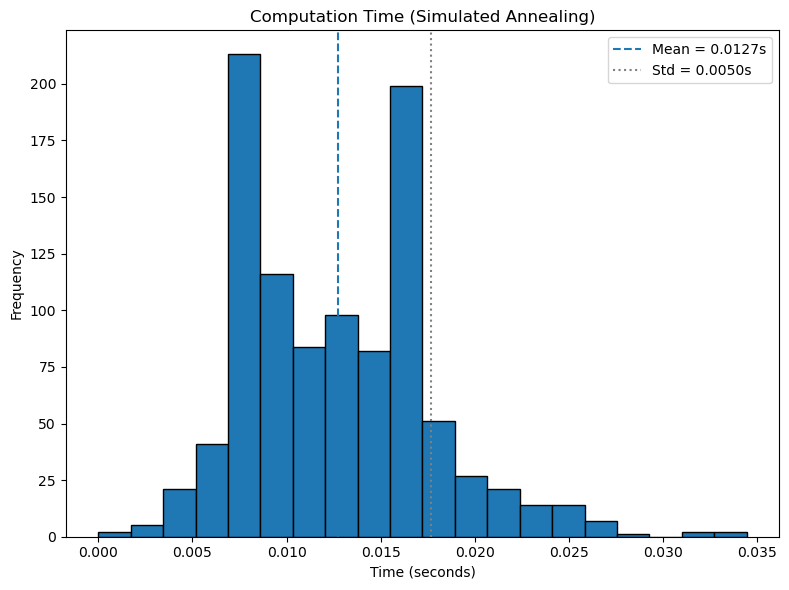

Mean computation time: 0.0127 seconds
Std deviation of time: 0.0050 seconds


(21.623249181371044,
 0.5706340387717319,
 0.01270595383644104,
 0.004954617814721881)

In [6]:
plot_distributions(initial_temp=100, num_of_cycle=300, runs=1000, max_attempts=10)